<a href="https://colab.research.google.com/github/nitindavegit/Deep-Learning/blob/main/pytorch09_ann_fashion_mnist_gpu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import pandas as pd
from sklearn.model_selection import train_test_split
import torch.optim as optim
import matplotlib.pyplot as plt

### set random seed value

In [35]:
torch.manual_seed(42)

### check for GPU

In [36]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device : {device}")


Using Device : cuda


In [37]:
df = pd.read_csv('/content/fashion-mnist_train.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,9,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,6,0,0,0,0,0,0,0,5,0,...,0.0,0.0,0.0,30.0,43.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0,0,1,2,0,0,0,0,...,3.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,3,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [38]:
df.shape

(36892, 785)

### Seeing how data looks like

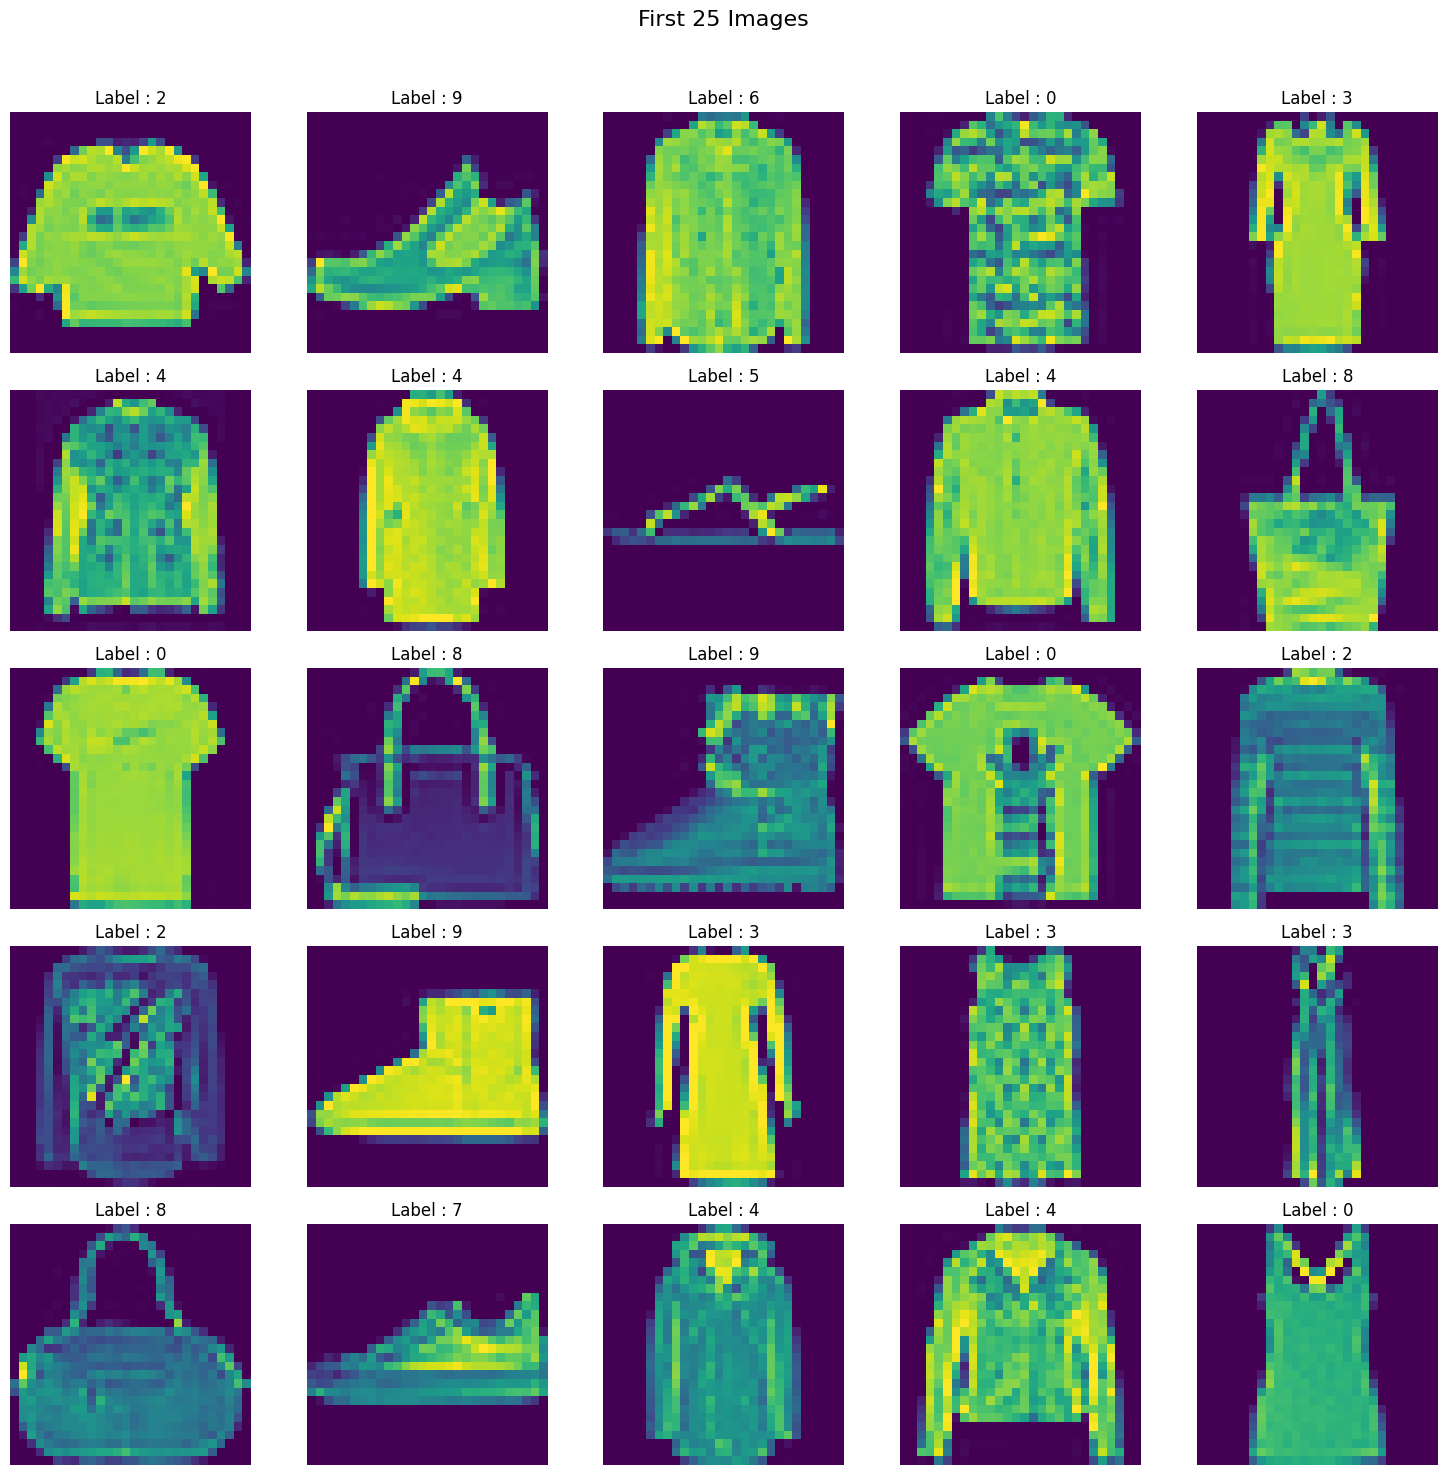

In [39]:
fig, axes = plt.subplots(5,5, figsize= (15,15))
fig.suptitle("First 25 Images", fontsize= 16)
for i , ax in enumerate(axes.flat):
  img = df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis('off')
  ax.set_title(f"Label : {df.iloc[i,0]}")

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

### Splitting train and test dataset

In [40]:
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

### Scaling the dataset

In [41]:
X_train = X_train / 255.0
X_test = X_test / 255.0

### Creating a CustomDataset using Dataset CLass

In [42]:
class CustomDataset(Dataset):
  def __init__(self, features, labels):
    self.features = torch.tensor(features.values, dtype=torch.float32)
    self.labels = torch.tensor(labels.values, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self,idx):
    return self.features[idx], self.labels[idx]

### Splitting both train and test dataset

In [43]:
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

### Creating dataloader class, pin memory is True for maximum efficiency

In [44]:
train_dataloader = DataLoader(train_dataset,batch_size=32, shuffle=True, pin_memory=True )
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True )

### Creating a neural network class

In [45]:
class MyNN(nn.Module):
  def __init__(self, num_features):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,10)
    )

  def forward (self, features):
    return self.model(features)

In [46]:
learning_rate = 0.1
epochs = 100

### Model is being loaded into GPU

In [47]:
model = MyNN(X_train.shape[1])
model = model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

criterion = nn.CrossEntropyLoss()

In [48]:
for epoch in range(epochs):
  total_epoch_loss = 0
  for batch_features, batch_labels in train_dataloader:

    # loading batch features and batch labels into GPU
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    y_pred = model(batch_features)
    loss = criterion(y_pred, batch_labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

  avg_loss = total_epoch_loss / len(train_dataloader)
  print(f"Epoch : {epoch + 1}, Loss : {avg_loss}")

Epoch : 1, Loss : 0.7275194768528509
Epoch : 2, Loss : 0.46700322960593205
Epoch : 3, Loss : 0.4154010762179014
Epoch : 4, Loss : 0.3851594577905674
Epoch : 5, Loss : 0.3585619860745458
Epoch : 6, Loss : 0.3429991319969313
Epoch : 7, Loss : 0.32798032801626564
Epoch : 8, Loss : 0.3141965561648296
Epoch : 9, Loss : 0.2998907453121208
Epoch : 10, Loss : 0.2904450970369907
Epoch : 11, Loss : 0.28410527937090024
Epoch : 12, Loss : 0.27287854225993285
Epoch : 13, Loss : 0.2626183367458415
Epoch : 14, Loss : 0.2543203993897203
Epoch : 15, Loss : 0.24895948166974122
Epoch : 16, Loss : 0.24209313165045315
Epoch : 17, Loss : 0.23403527071640978
Epoch : 18, Loss : 0.22645473044732928
Epoch : 19, Loss : 0.22007511427196172
Epoch : 20, Loss : 0.2172517915168537
Epoch : 21, Loss : 0.2099559681927977
Epoch : 22, Loss : 0.20856255345361333
Epoch : 23, Loss : 0.20526602177932166
Epoch : 24, Loss : 0.19667682090102173
Epoch : 25, Loss : 0.18908779632667422
Epoch : 26, Loss : 0.18564838129030148
Epoch :

In [49]:
model.eval()

total = 0
correct = 0
with torch.no_grad():

  for batch_features, batch_labels in test_dataloader:


    # Loading batch features and batch labels in train dataset into GPU
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    y_pred = model(batch_features)

    total = total + batch_labels.shape[0]

    _,predicted = torch.max(y_pred,1)

    correct=  correct + (predicted == batch_labels).sum().item()



avg_accuracy = correct/total
print(f"Accuracy : {avg_accuracy}")



Accuracy : 0.8864344762162895
